<a href="https://colab.research.google.com/github/canseel/gelecek-hayalim-wcode/blob/main/week6_1_homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gelecek Hayalim: W-Code 2.0 Veri Bilimi ve Yapay Zeka Atolyesi 3. Donem Homework Week 6-**1**

Bu ödevde seçtiğimiz bir veri seti üzerinde veri analizi yapmam gerekiyor.
Kaggle üzerinden ilgimi çeken bir veri seti indirdim.


Şimdi bu veri setini okuyalım

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("Student Mental health.csv", sep=';')
df

,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,8.07.2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8.07.2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8.07.2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8.07.2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8.07.2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...
96,13.07.2020 19:56,Female,21.0,BCS,year 1,3.50 - 4.00,No,No,Yes,No,No
97,13.07.2020 21:21,Male,18.0,Engineering,Year 2,3.00 - 3.49,No,Yes,Yes,No,No
98,13.07.2020 21:22,Female,19.0,Nursing,Year 3,3.50 - 4.00,Yes,Yes,No,Yes,No
99,13.07.2020 21:23,Female,23.0,Pendidikan Islam,year 4,3.50 - 4.00,No,No,No,No,No


* pd.read_csv("Student Mental health.csv") ile okumaya çalıştım fakat veri tek sütuna sıkıştı.  → pd.read_csv("Student Mental health.csv", sep=';') kullanarak doğru sütunlara ayırdım

In [ ]:
df.info() #Öğrencilerin mental sağlıklarını hangi başlıklarda inceleyeceğimize göz atalım

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 11 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Timestamp                                     101 non-null    object 
 1   Choose your gender                            101 non-null    object 
 2   Age                                           100 non-null    float64
 3   What is your course?                          101 non-null    object 
 4   Your current year of Study                    101 non-null    object 
 5   What is your CGPA?                            101 non-null    object 
 6   Marital status                                101 non-null    object 
 7   Do you have Depression?                       101 non-null    object 
 8   Do you have Anxiety?                          101 non-null    object 
 9   Do you have Panic attack?                     101 non-null    obj

In [ ]:
df.isnull().any() #eksik değer olup olmadığını kontrol edelim

,0
Timestamp,False
Choose your gender,False
Age,True
What is your course?,False
Your current year of Study,False
What is your CGPA?,False
Marital status,False
Do you have Depression?,False
Do you have Anxiety?,False
Do you have Panic attack?,False


* Age sütununda eksik değer tespit ettik şimdi bu eksik değer sayısını belirleyelim.   



In [ ]:
df["Age"].isnull().sum()

np.int64(1)

In [ ]:
df["Age"].unique() #Analizi yaş gruplarına göre yapmayı planladığım için öğrencilerin yaş skalasını öğrenmek istiyorum

array([18., 21., 19., 22., 23., 20., 24., nan])

# **18 YAŞ**

In [ ]:
df18 = df[df['Age'] == 18] #18 yaş için filtreleme yaptım

In [ ]:
eightteen_age_depression_analyses = df18.groupby('Do you have Depression?').size() #18 yaşındaki öğrencilerde depresyon durumu
eightteen_age_depression_analyses

,0
Do you have Depression?,
No,21
Yes,11


In [ ]:
eightteen_age_anxiety_analyses = df18.groupby('Do you have Anxiety?').size() #18 yaşındaki öğrencilerde anksiyete durumu
eightteen_age_anxiety_analyses

,0
Do you have Anxiety?,
No,18
Yes,14


In [ ]:
eightteen_age_panic_analyses = df18.groupby('Do you have Panic attack?').size() #18 yaşındaki öğrencilerde panik durumu
eightteen_age_panic_analyses

,0
Do you have Panic attack?,
No,23
Yes,9


In [ ]:
eightteen_age_specialist_analyses = df18.groupby('Did you seek any specialist for a treatment?').size() #18 yaşındaki öğrencilerde uzmandan destek alma durumu
eightteen_age_specialist_analyses

,0
Did you seek any specialist for a treatment?,
No,30
Yes,2


Şimdi bu verileri görselleştirelim

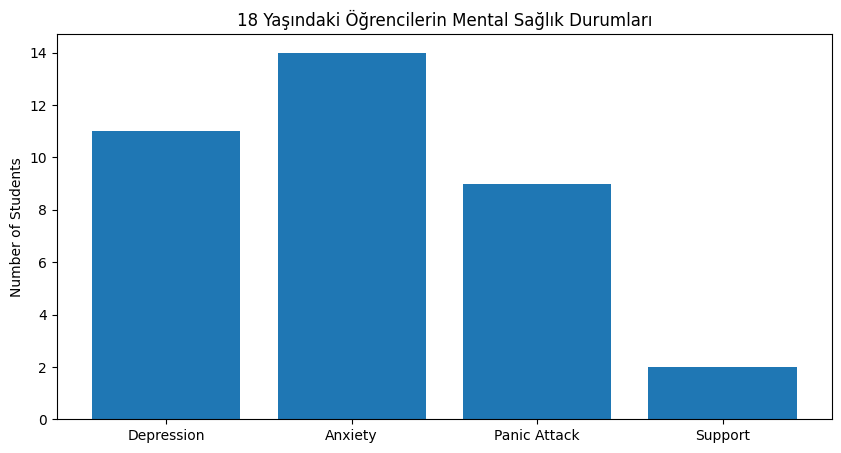

In [ ]:
#Bu kategorilerdeki öğrenci sayılarını göstermek için cevabı yes olanları sayalım
dep = (df18["Do you have Depression?"] == "Yes").sum()
anx = (df18["Do you have Anxiety?"] == "Yes").sum()
pan = (df18["Do you have Panic attack?"] == "Yes").sum()
sup = (df18["Did you seek any specialist for a treatment?"] == "Yes").sum()

plt.figure(figsize=(10,5))
plt.bar(["Depression", "Anxiety", "Panic Attack", "Support"], [dep, anx, pan, sup])
plt.ylabel("Number of Students")
plt.title("18 Yaşındaki Öğrencilerin Mental Sağlık Durumları")
plt.show()


# **19 YAŞ**

Her bir yaş grubu için tüm koşullar tek tek aynı şekilde değerlendirilebilir ancak diğer yaş grupları için yalnızca grafikleri görüntüleyeceğim

In [ ]:
df19 = df[df['Age'] == 19] #19 yaş için filtreleme yaptım

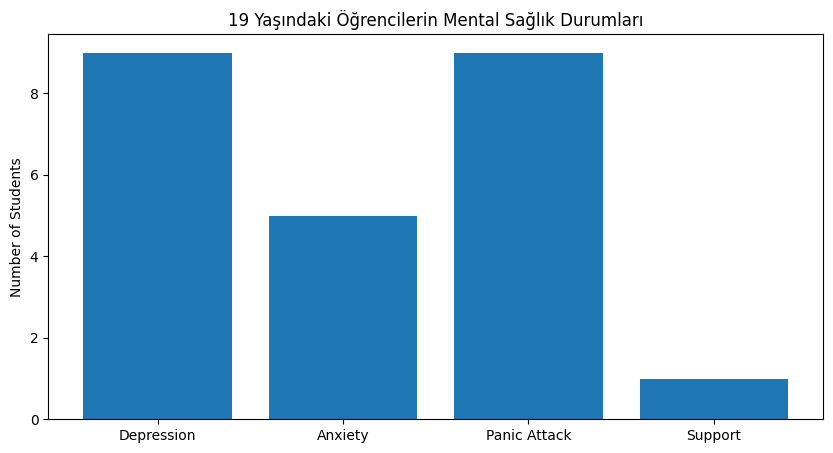

In [ ]:
dep = (df19["Do you have Depression?"] == "Yes").sum()
anx = (df19["Do you have Anxiety?"] == "Yes").sum()
pan = (df19["Do you have Panic attack?"] == "Yes").sum()
sup = (df19["Did you seek any specialist for a treatment?"] == "Yes").sum()

plt.figure(figsize=(10,5))
plt.bar(["Depression", "Anxiety", "Panic Attack", "Support"], [dep, anx, pan, sup])
plt.ylabel("Number of Students")
plt.title("19 Yaşındaki Öğrencilerin Mental Sağlık Durumları")
plt.show()

Martial status- Depression Analyses

In [ ]:
statu_depressiom = df.groupby(['Marital status', 'Do you have Depression?']).size()
statu_depressiom

Marital status  Do you have Depression?
No              No                         66
                Yes                        19
Yes             Yes                        16
dtype: int64